# Problem Statement

XYZ company 2014-2018 sales data to identify key revenue and profit drivers across products, channels, and regions,uncover seasonal trends and outliers and align performance against budgests. use these insight to optimize pricing,promotions,and marketing expansion for sustinable growth and reduced concentration risk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sheets=pd.read_excel('/content/Regional Sales Dataset.xlsx',sheet_name=None)

In [ ]:
# Assign dataframe to each sheet

df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_products=sheets['Products']
df_regions=sheets['Regions']
df_state_reg=sheets['State Regions']
df_budgets=sheets['2017 Budgets']


In [ ]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [ ]:
df_sales.shape

(64104, 12)

In [ ]:
print('df_sales shape:' ,df_sales.shape)
print('df_customers shape:' ,df_customers.shape)
print('df_products shape:' ,df_products.shape)
print('df_regions shape:' ,df_regions.shape)
print('df_state_reg shape:' ,df_state_reg.shape)
print('df_budgets shape:' ,df_budgets.shape)

df_sales shape: (64104, 12)
df_customers shape: (175, 2)
df_products shape: (30, 2)
df_regions shape: (994, 15)
df_state_reg shape: (49, 3)
df_budgets shape: (30, 2)


In [ ]:
df_state_reg.head(5)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [ ]:
new_header=df_state_reg.iloc[0]
df_state_reg=df_state_reg[1:].reset_index(drop=True)
df_state_reg.columns=new_header

df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


Data Cleaning and Wrangling

In [ ]:
# Merge with Customers
df=df_sales.merge(df_customers,how='left', left_on='Customer Name Index', right_on='Customer Index')


In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [ ]:
# Merge with Products
df=df.merge(df_products, how='left', left_on='Product Description Index', right_on='Index')

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [ ]:
# Merge with Regions
df=df.merge(df_regions, how='left', left_on='Delivery Region Index', right_on='id')

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [ ]:
# Merge with Budget
df=df.merge(df_budgets, how='left', on='Product Name')

In [ ]:
# Merge with state Regions

df=df.merge(df_state_reg[['State Code','Region']] , how='left', left_on='state_code', right_on='State Code')

In [ ]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,2017 Budgets,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,964940.231,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,2067108.120,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,5685138.270,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,889737.555,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,1085037.329,CT,Northeast


In [ ]:
df.to_csv('file.csv')

In [ ]:
# Customer Index
#Index
#id
#State Code

# Clean up redundant columns

cols_to_drop=['Customer Index','Index','id','State Code']

df=df.drop(columns=cols_to_drop, errors='ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,2017 Budgets,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,964940.231,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,2067108.120,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,5685138.270,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,889737.555,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,1085037.329,Northeast


In [ ]:
# Convert all columns to lower case for consistency and easier access
df.columns=df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone',
       '2017 budgets', 'region'], dtype=object)

In [ ]:
# Keep the important columns and delete the columns that we don't need
cols_to_keep=[
    'ordernumber', 'orderdate','channel','customer names', 'product name','order quantity','unit price','line total', 'total unit cost','county', 'state_code','region',
    '2017 budgets','state','longitude','latitude'
]


In [ ]:
df=df[cols_to_keep]

In [ ]:
df.head(5)

,ordernumber,orderdate,channel,customer names,product name,order quantity,unit price,line total,total unit cost,county,state_code,region,2017 budgets,state,longitude,latitude
0,SO - 000225,2014-01-01,Wholesale,Rhynoodle Ltd,Product 27,6,2499.1,14994.6,1824.343,Chatham County,GA,South,964940.231,Georgia,-81.09983,32.08354
1,SO - 0003378,2014-01-01,Distributor,Thoughtmix Ltd,Product 20,11,2351.7,25868.7,1269.918,Johnson County,IN,Midwest,2067108.120,Indiana,-86.10665,39.61366
2,SO - 0005126,2014-01-01,Wholesale,Amerisourc Corp,Product 26,6,978.2,5869.2,684.740,Alameda County,CA,West,5685138.270,California,-121.87468,37.66243
3,SO - 0005614,2014-01-01,Export,Colgate-Pa Group,Product 7,7,2338.3,16368.1,1028.852,Monroe County,IN,Midwest,889737.555,Indiana,-86.52639,39.16533
4,SO - 0005781,2014-01-01,Wholesale,Deseret Group,Product 8,8,2291.4,18331.2,1260.270,Hartford County,CT,Northeast,1085037.329,Connecticut,-72.52443,41.77524


In [ ]:
# Rename the columns
df=df.rename(columns={
    'ordernumber':'order_number',
    'orderdate':'order_date',
    'channel':'channel',
    'customer names':'customer_name',
    'product name':'product_name',
    'order quantity':'order_quantity',
    'unit price':'unit_price',
    'line total':'revenue',
    'total unit cost':'total_unit_cost',
    'county':'county',
    'region':'region',
    'state_code':'state',
    '2017 budgets':'budget',
    'state':'state_name',
    'longitude':'lon',
    'latitude':'lat'
})

In [ ]:
df.head(1)

,order_number,order_date,channel,customer_name,product_name,order_quantity,unit_price,revenue,total_unit_cost,county,state,region,budget,state_name,lon,lat
0,SO - 000225,2014-01-01,Wholesale,Rhynoodle Ltd,Product 27,6,2499.1,14994.6,1824.343,Chatham County,GA,South,964940.231,Georgia,-81.09983,32.08354


In [ ]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

# line total is revenue
df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   channel          64104 non-null  object        
 3   customer_name    64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total_unit_cost  64104 non-null  float64       
 9   county           64104 non-null  object        
 10  state            64104 non-null  object        
 11  region           64104 non-null  object        
 12  budget           15263 non-null  float64       
 13  state_name       64104 non-null  object        
 14  lon              64104 non-null  float

In [ ]:
# Filter the dataset to include only records from the year 2017
df_2017=df[df['order_date'].dt.year==2017]

In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
channel,0
customer_name,0
product_name,0
order_quantity,0
unit_price,0
revenue,0
total_unit_cost,0
county,0


In [ ]:
df_2017.head(5)

,order_number,order_date,channel,customer_name,product_name,order_quantity,unit_price,revenue,total_unit_cost,county,state,region,budget,state_name,lon,lat
46363,SO - 0002544,2017-01-01,Wholesale,NCS Group,Product 30,6,1239.5,7437.0,1028.785,Hudson County,NJ,Northeast,1011609.684,New Jersey,-74.02375,40.77955
46364,SO - 0006431,2017-01-01,Wholesale,Epic Group,Product 13,5,1829.1,9145.5,1207.206,Mesa County,CO,West,3720639.645,Colorado,-108.55065,39.06387
46365,SO - 0007491,2017-01-01,Wholesale,State Ltd,Product 15,9,2412.0,21708.0,1664.280,Los Angeles County,CA,West,3299478.315,California,-118.35313,33.96168
46366,SO - 0008741,2017-01-01,Wholesale,Fivebridge Ltd,Product 8,8,904.5,7236.0,750.735,Dubuque County,IA,Midwest,1085037.329,Iowa,-90.66457,42.50056
46367,SO - 0009295,2017-01-01,Wholesale,Tagfeed Ltd,Product 2,12,1112.2,13346.4,811.906,Hernando County,FL,South,3050087.565,Florida,-82.52546,28.47689


#Feature Engineering

In [ ]:
df['total_cost']=df['order_quantity']*df['total_unit_cost']

In [ ]:
df['profit']=df['revenue']-df['total_cost']

In [ ]:
df['profit_margin']=df['profit']/df['revenue']*100

In [ ]:
df.head(5)

,order_number,order_date,channel,customer_name,product_name,order_quantity,unit_price,revenue,total_unit_cost,county,state,region,budget,state_name,lon,lat,total_cost,profit,profit_margin
0,SO - 000225,2014-01-01,Wholesale,Rhynoodle Ltd,Product 27,6,2499.1,14994.6,1824.343,Chatham County,GA,South,NaN,Georgia,-81.09983,32.08354,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,Thoughtmix Ltd,Product 20,11,2351.7,25868.7,1269.918,Johnson County,IN,Midwest,NaN,Indiana,-86.10665,39.61366,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Wholesale,Amerisourc Corp,Product 26,6,978.2,5869.2,684.740,Alameda County,CA,West,NaN,California,-121.87468,37.66243,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Export,Colgate-Pa Group,Product 7,7,2338.3,16368.1,1028.852,Monroe County,IN,Midwest,NaN,Indiana,-86.52639,39.16533,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Wholesale,Deseret Group,Product 8,8,2291.4,18331.2,1260.270,Hartford County,CT,Northeast,NaN,Connecticut,-72.52443,41.77524,10082.160,8249.040,45.0


#EDA

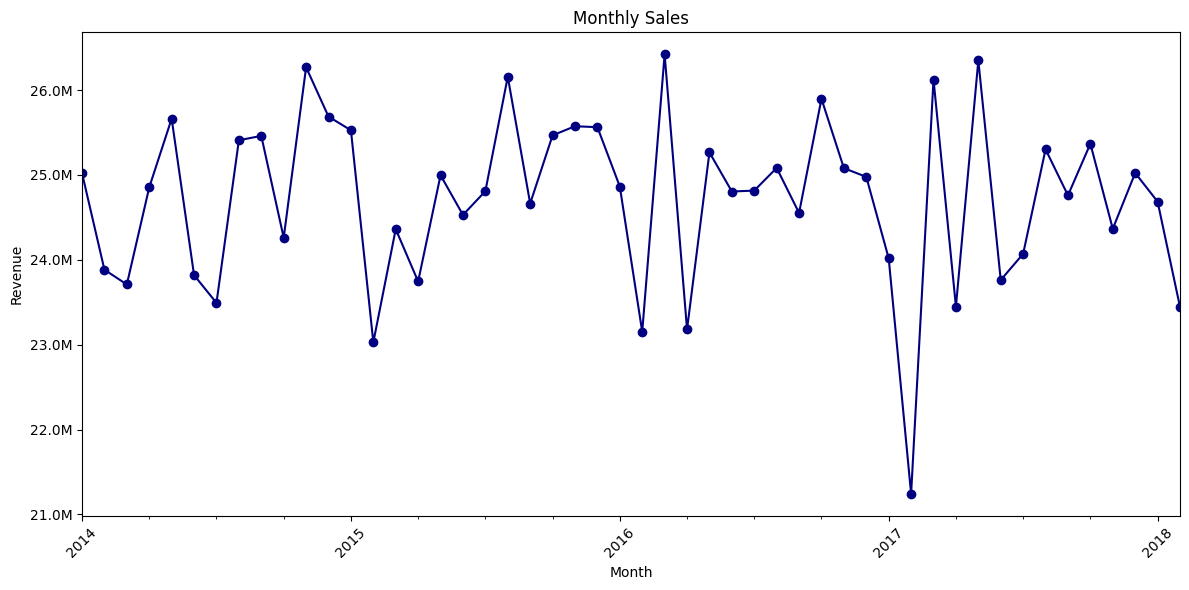

In [ ]:
df['order_month']=df['order_date'].dt.to_period('M')
monthly_sales=df.groupby('order_month')['revenue'].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o',color='navy')
from matplotlib.ticker import FuncFormatter
formatter=FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')

plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

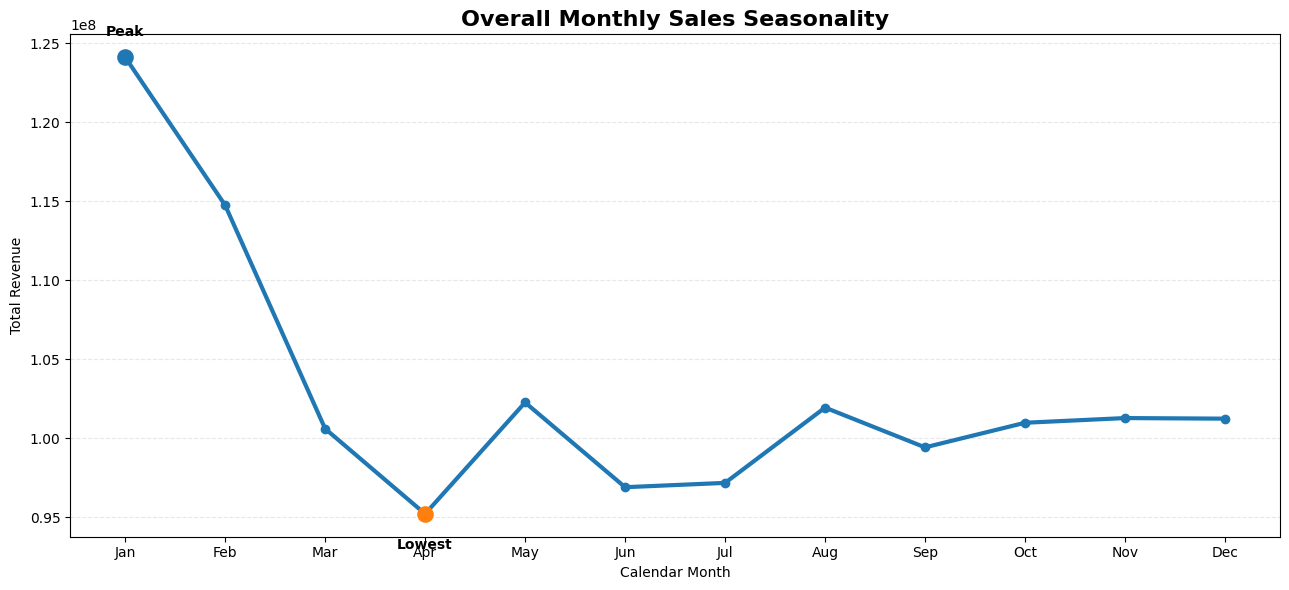

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['order_date'] = pd.to_datetime(df['order_date'])

# Month number
df['month_num'] = df['order_date'].dt.month

# Total revenue by calendar month across ALL years
monthly_sales = (
    df.groupby('month_num', as_index=False)['revenue']
      .sum()
)

# Month names
monthly_sales['month'] = pd.to_datetime(
    monthly_sales['month_num'],
    format='%m'
).dt.strftime('%b')

# Sort January -> December
monthly_sales = monthly_sales.sort_values('month_num')

# Plot
plt.figure(figsize=(13, 6))

plt.plot(
    monthly_sales['month'],
    monthly_sales['revenue'],
    marker='o',
    linewidth=3
)

# Highlight highest and lowest months
max_idx = monthly_sales['revenue'].idxmax()
min_idx = monthly_sales['revenue'].idxmin()

plt.scatter(
    monthly_sales.loc[max_idx, 'month'],
    monthly_sales.loc[max_idx, 'revenue'],
    s=120,
    zorder=5
)

plt.scatter(
    monthly_sales.loc[min_idx, 'month'],
    monthly_sales.loc[min_idx, 'revenue'],
    s=120,
    zorder=5
)

plt.annotate(
    'Peak',
    (
        monthly_sales.loc[max_idx, 'month'],
        monthly_sales.loc[max_idx, 'revenue']
    ),
    xytext=(0, 15),
    textcoords='offset points',
    ha='center',
    fontweight='bold'
)

plt.annotate(
    'Lowest',
    (
        monthly_sales.loc[min_idx, 'month'],
        monthly_sales.loc[min_idx, 'revenue']
    ),
    xytext=(0, -25),
    textcoords='offset points',
    ha='center',
    fontweight='bold'
)

plt.title(
    'Overall Monthly Sales Seasonality',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Calendar Month')
plt.ylabel('Total Revenue')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

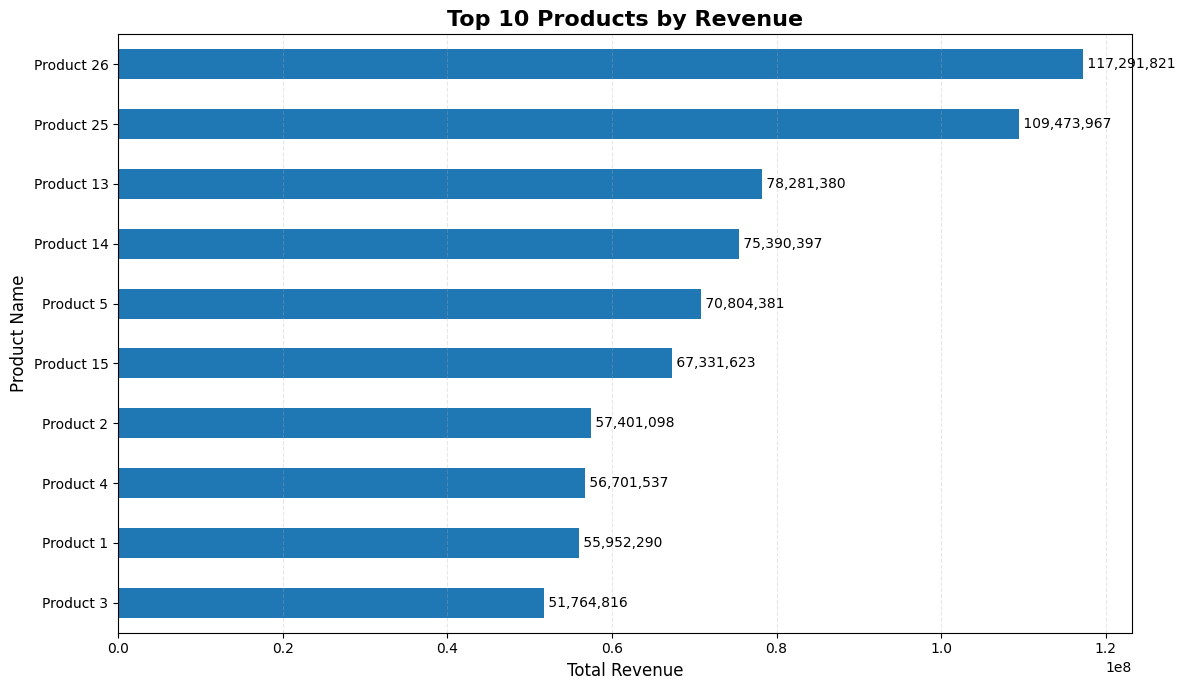

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure revenue is numeric
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Top 10 products by total revenue
top_10_products = (
    df.groupby('product_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12, 7))

ax = top_10_products.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Add revenue values to bars
for i, value in enumerate(top_10_products.sort_values()):
    ax.text(
        value,
        i,
        f' {value:,.0f}',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

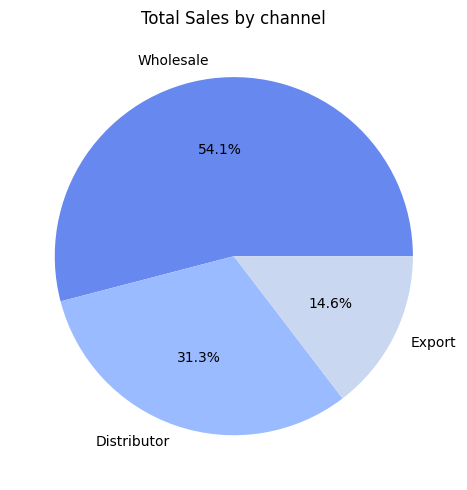

In [ ]:
# Sales by channel

chan_sale=df.groupby('channel')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(5,5))
plt.pie(
    chan_sale,
    labels=chan_sale.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by channel')
plt.tight_layout()
plt.show()

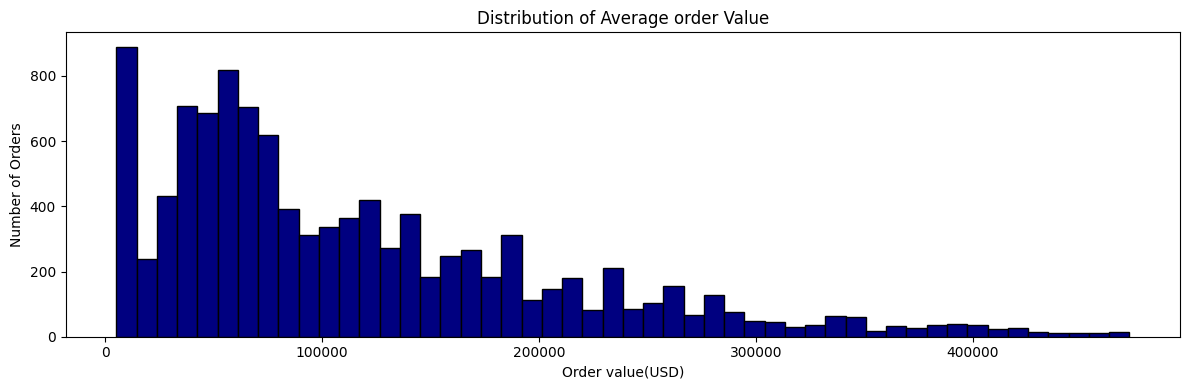

In [ ]:
# Average order value distribution

aov=df.groupby('order_number')['revenue'].sum()
plt.figure(figsize=(12,4))
plt.hist(
    aov,
    bins=50,
    color='navy',
    edgecolor='black'
    )
plt.title('Distribution of Average order Value')
plt.xlabel('Order value(USD)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()


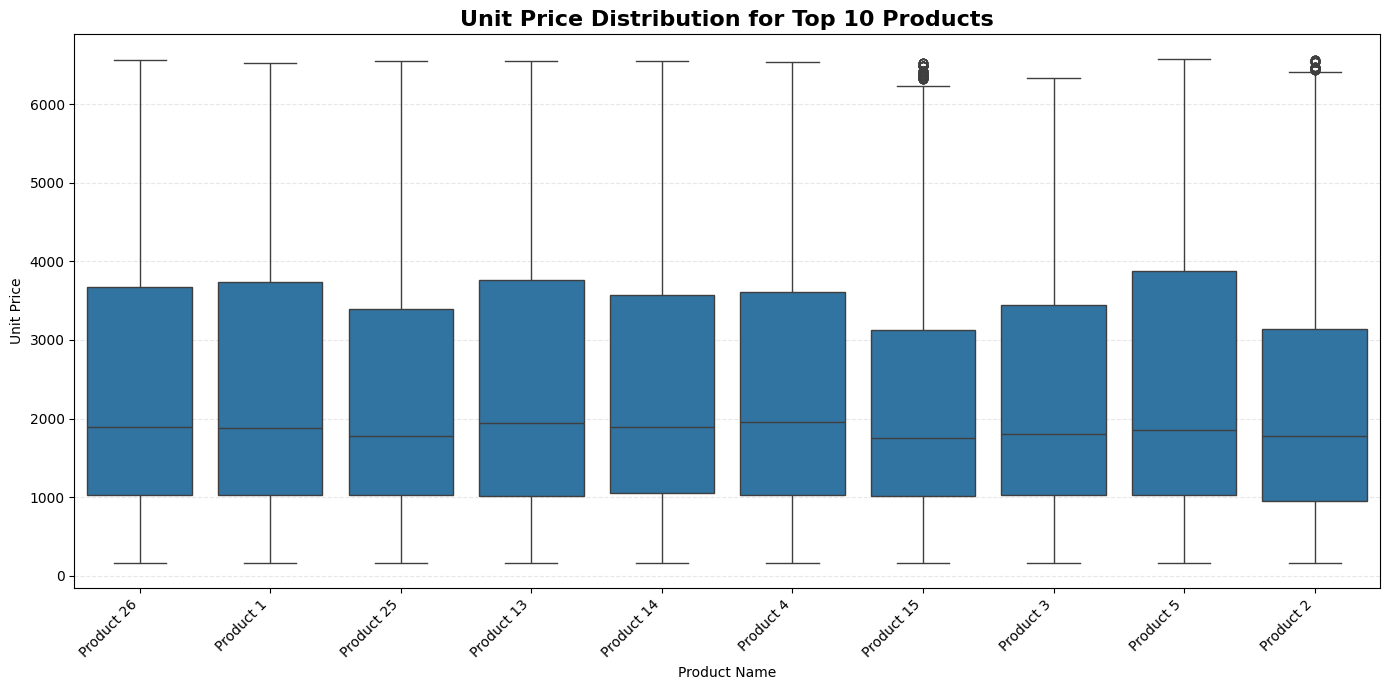

In [ ]:
# unit price distribution per product
# Top 10 states by revenue and order count
# Average profit margin by channel
# Top and Bottom 10 customers by revenue
# Customer segmentation: Revenue vs Profit Margin
# Correlation Heatmap

top_products = df['product_name'].value_counts().head(10).index

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[df['product_name'].isin(top_products)],
    x='product_name',
    y='unit_price'
)

plt.title('Unit Price Distribution for Top 10 Products',
          fontsize=16, fontweight='bold')

plt.xlabel('Product Name')
plt.ylabel('Unit Price')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

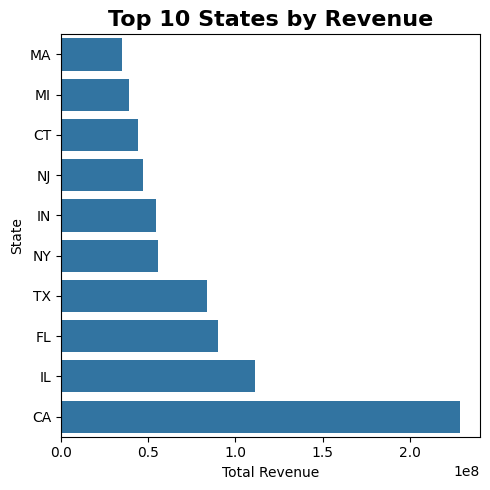

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 states by revenue
top_10_revenue = (
    df.groupby('state')['revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(5, 5))

sns.barplot(
    x=top_10_revenue.values,
    y=top_10_revenue.index
)

plt.title('Top 10 States by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('State')

plt.tight_layout()
plt.show()


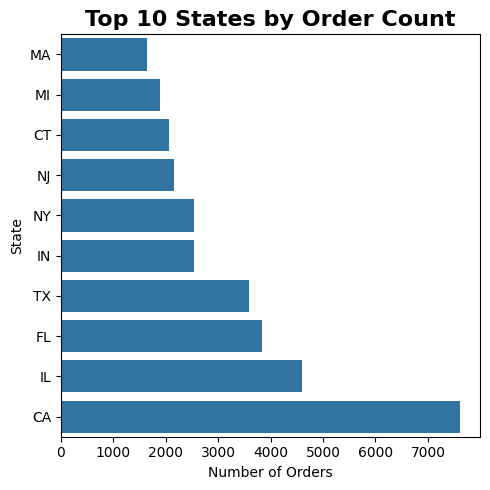

In [ ]:
# Top 10 states by unique order count
top_10_orders = (
    df.groupby('state')['order_number']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(5, 5))

sns.barplot(
    x=top_10_orders.values,
    y=top_10_orders.index
)

plt.title('Top 10 States by Order Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('State')

plt.tight_layout()
plt.show()

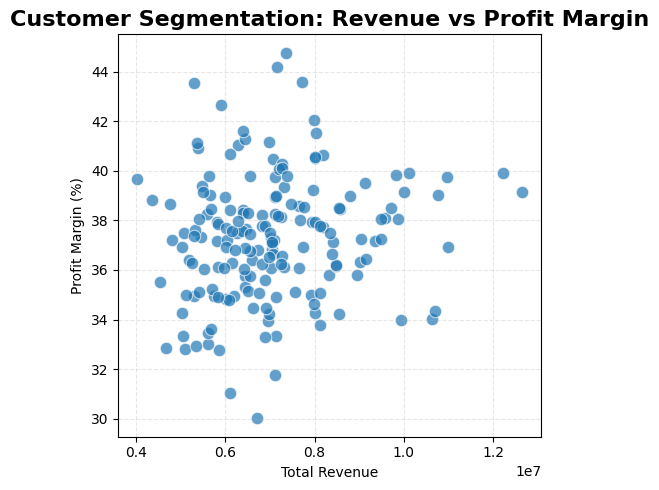

In [ ]:

# Aggregate customer-level data
customer_data = (
    df.groupby('customer_name')
      .agg(
          revenue=('revenue', 'sum'),
          profit=('profit', 'sum')
      )
      .reset_index()
)

# Calculate customer-level profit margin
customer_data['profit_margin'] = (
    customer_data['profit'] / customer_data['revenue'] * 100
)

# Remove invalid values
customer_data = customer_data.replace(
    [float('inf'), -float('inf')],
    pd.NA
).dropna(subset=['revenue', 'profit_margin'])

# Plot
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=customer_data,
    x='revenue',
    y='profit_margin',
    s=80,
    alpha=0.7
)

plt.title(
    'Customer Segmentation: Revenue vs Profit Margin',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Total Revenue')
plt.ylabel('Profit Margin (%)')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

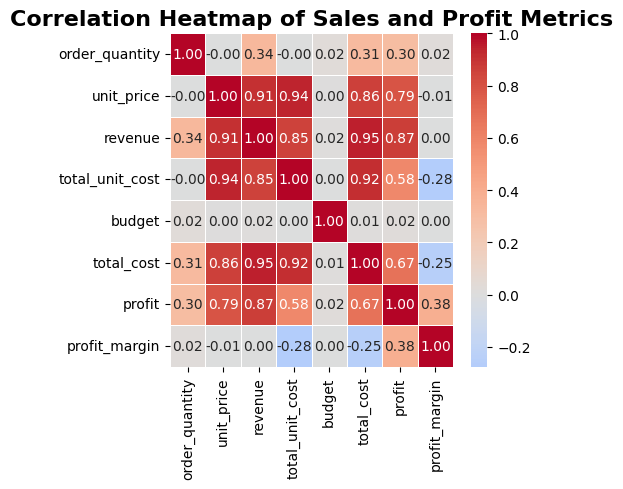

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation
corr_columns = [
    'order_quantity',
    'unit_price',
    'revenue',
    'total_unit_cost',
    'budget',
    'total_cost',
    'profit',
    'profit_margin'
]

# Calculate correlation matrix
correlation_matrix = df[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(5, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title(
    'Correlation Heatmap of Sales and Profit Metrics',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()